** Assignment 9
By
Manuela Mouafo
&
Sam-Haendell Thosiac **


#What Factors Lead To Cancelled Bookings?

The Letoh Hotel Group has a few factors that lead to cancelled bookings. For example, their City Hotel has a higher percentage of cancellations (At 40%) in comparison to the Resort Hotel. What they could do to combat this is to increase the Booking amounts they have at the Resort Hotel, seeing as more people cancel their reservations at the City Hotel.

Another recomedndation I would make is to decrease their booking dates for the Summer because that specific season has a higher chance of being canceled than in the fall, Spring, and Summer. In addition, their Winter season has a lower percentage of being cancelled, so they can spend some money on marketing their Hotel around the winter months to bring more customers in, as this season has a lower percentage of being cancelled.

We also did a correlation analysis to identify the specific variables that may lead to past cancellations. We saw that there is a high correlation between "previous_cancellations" and the "lead_time". This would mean that in the past there is a high correlation between the people that have a higher number of days between when they book in the Letoh Hotel system vs when their arrival date and the previous_cancellations. So people who have longer days between when they book vs. the arrival date of their booking have a higher change of being cancelled.


#What is the Estimated Impact of Minimizing Cancellations

We ran a logistic regression model to predict whether a booking is canceled (1) or not cancelled (0).The model performs well with 82% accuracy, showing that it can distinguish between canceled and non-canceled bookings effectively. However, because recall for canceled bookings is only 0.66, the model misses a meaningful share of actual cancellations, which means the model can support business decisions, such as tabookeded reminders about your booking and confirmation outreach (ensuring you know when your booking is), but it should not be used as the only method for managing cancellation risk.

B.
Letoh Hotel Group can make a rule in their system that you cannot book more than 5 days in advance for your Hotel stays at either hotel. This would lower the Lead time and lead to a decrease amount int he number of people who have cancelled in the past. This would also mean opening or even expanding their Hotel rooms to fit the increase in shorter stays that this rule would come with because people would no longer be able to book in advance as much as they want.

C. The Impact on revenue is that there is a high non-refund amount for those who have cancelled. So that would mean that there is more money in the Letoh Hotel Group from the customers who did not receive a refund back after their booking had been cancelled.

Importing Libraries and Reading data

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from string import ascii_letters

df = pd.read_csv("/content/hotel_bookings.csv")


Here, we will be adjusting our data and changing some of the formats to make it easier tio read but also to model. We have changed the values from Upper case to lowercase but have also replaced the na values of children with 0 as they were initially numbers adn did the same for countries with ni name and replaced them to Unknown.

In [ ]:
df.columns = df.columns.str.lower()
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna("Unknown")
df = df.dropna(subset=['adr'])
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103886,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398555,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
df.isna().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
df = df.drop(columns=['agent', 'company', 'reservation_status', 'reservation_status_date'])
df.isna().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


Here we created four new features to help the model our efficiency for this task:
total_nights adds weekend and weekday nights together,
 is_family marks whether kids are part of the booking suing dummiy variables
 room_mismatch checks if the guest got a different room than they booked,
 and season converts the month into a season so the model can learn seasonal patterns.

In [ ]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['is_family'] = np.where(df['children'] + df['babies'] > 0, 1, 0)
df['room_mismatch'] = np.where(df['reserved_room_type'] != df['assigned_room_type'], 1, 0)
df['season'] = df['arrival_date_month'].map({
    'December':'Winter','January':'Winter','February':'Winter',
    'March':'Spring','April':'Spring','May':'Spring',
    'June':'Summer','July':'Summer','August':'Summer',
    'September':'Fall','October':'Fall','November':'Fall'
})
df


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_nights,is_family,room_mismatch,season
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0,Transient,0.00,0,0,0,0,0,Summer
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0,Transient,0.00,0,0,0,0,0,Summer
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0,Transient,75.00,0,0,1,0,1,Summer
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,0,Transient,75.00,0,0,1,0,0,Summer
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,0,Transient,98.00,0,1,2,0,0,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,0,Transient,96.14,0,0,7,0,0,Summer
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,0,Transient,225.43,0,2,7,0,0,Summer
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,0,Transient,157.71,0,4,7,0,0,Summer
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,0,Transient,104.40,0,0,7,0,0,Summer


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

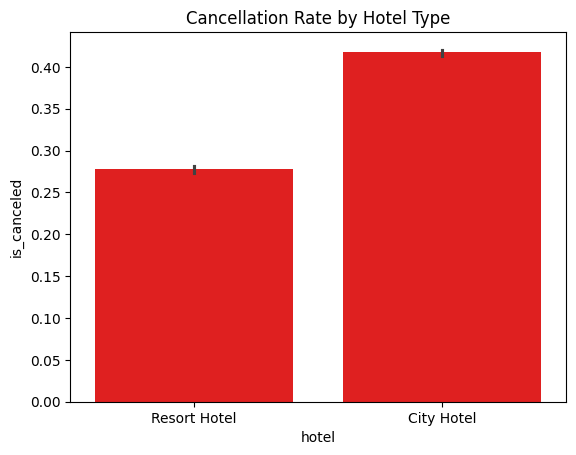

In [ ]:
sns.barplot(data=df, x='hotel', y='is_canceled', color = "red")
plt.title("Cancellation Rate by Hotel Type")
plt.show()


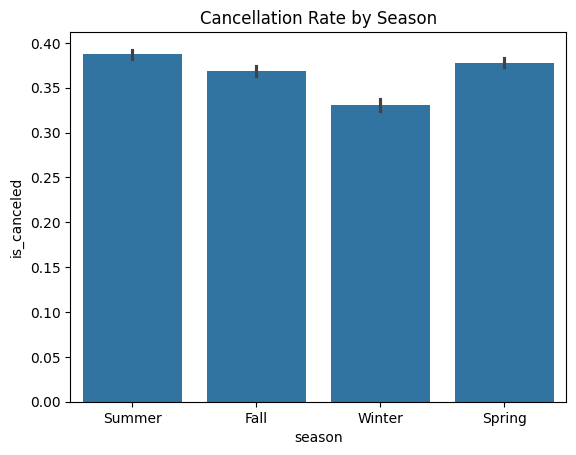

In [ ]:
sns.barplot(data=df, x='season', y='is_canceled')
plt.title("Cancellation Rate by Season")
plt.show()

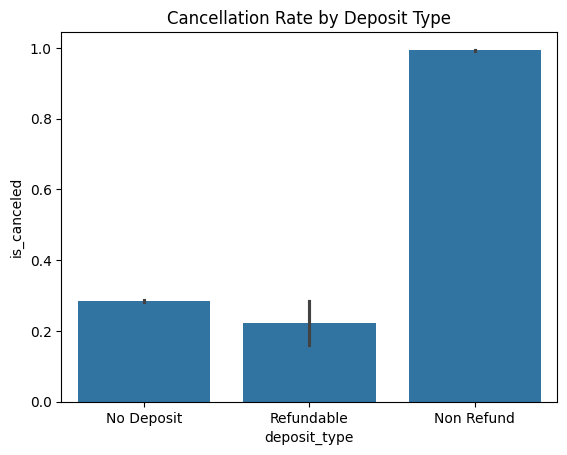

In [ ]:
sns.barplot(data=df, x='deposit_type', y='is_canceled')
plt.title("Cancellation Rate by Deposit Type")
plt.show()

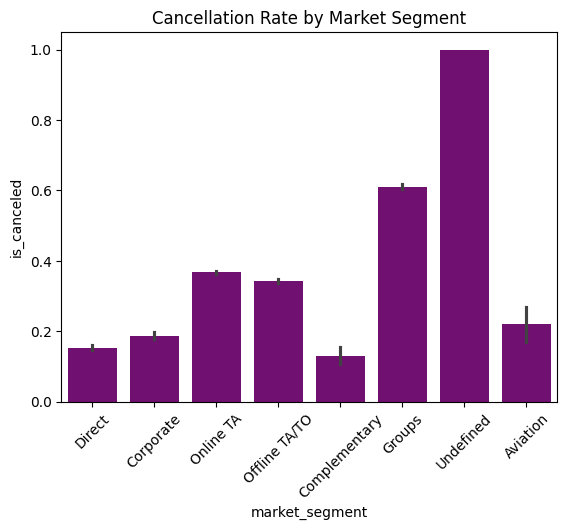

In [ ]:
sns.barplot(data=df, x='market_segment', color = "purple", y='is_canceled')
plt.xticks(rotation=45)
plt.title("Cancellation Rate by Market Segment")
plt.show()

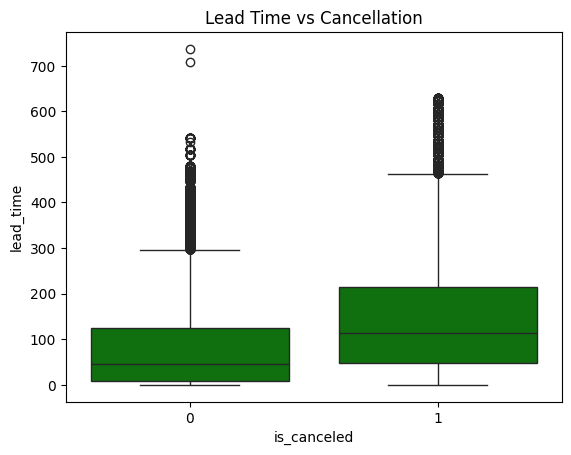

In [ ]:
sns.boxplot(data=df, x='is_canceled', y='lead_time', color = "green")
plt.title("Lead Time vs Cancellation")
plt.show()

                                previous_cancellations  \
previous_cancellations                        1.000000   
previous_bookings_not_canceled                0.152728   
booking_changes                              -0.026993   
lead_time                                     0.086042   
stays_in_weekend_nights                      -0.012775   
stays_in_week_nights                         -0.013992   

                                previous_bookings_not_canceled  \
previous_cancellations                                0.152728   
previous_bookings_not_canceled                        1.000000   
booking_changes                                       0.011608   
lead_time                                            -0.073548   
stays_in_weekend_nights                              -0.042715   
stays_in_week_nights                                 -0.048743   

                                booking_changes  lead_time  \
previous_cancellations                -0.026993   0.086042   
previo

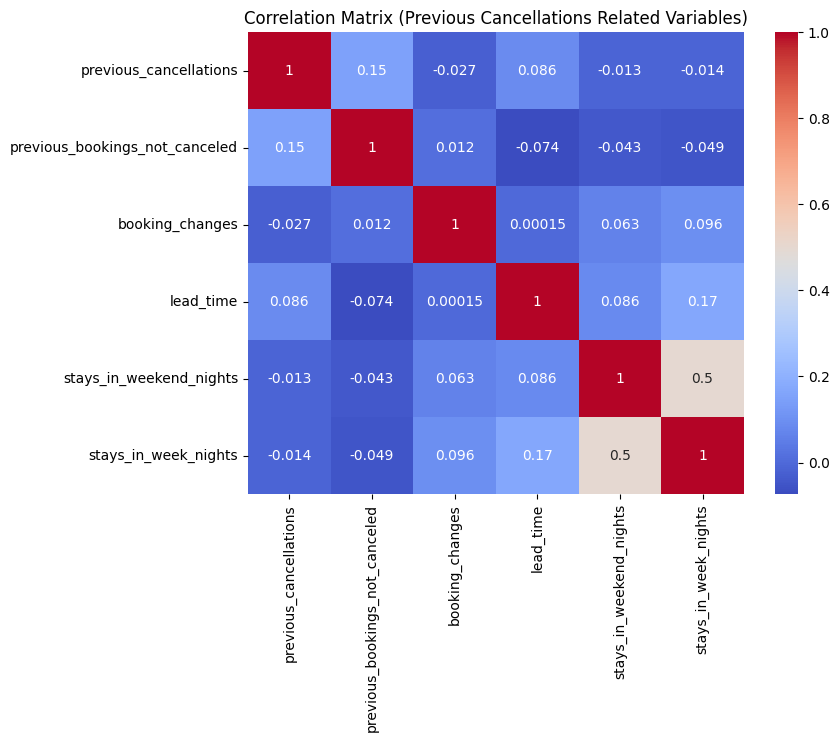

In [ ]:
cols = [
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights"
]

df_subset = df[cols]
corr_matrix = df_subset.corr()
print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (Previous Cancellations Related Variables)")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

categorical = X.select_dtypes(include=['object']).columns
numeric = X.select_dtypes(exclude=['object']).columns

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
        ('num', 'passthrough', numeric)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# Here we are defining which values are categorical and numerical.
#Categorical → labels, names, types, cities, countries
#Numeric → counts, rates, durations, prices, discounts etc


categorical = [
    'hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
    'distribution_channel', 'reserved_room_type', 'assigned_room_type',
    'deposit_type', 'customer_type', 'season'
]

numeric = [
    'lead_time', 'arrival_date_year', 'arrival_date_week_number',
    'arrival_date_day_of_month', 'stays_in_weekend_nights',
    'stays_in_week_nights', 'adults', 'children', 'babies',
    'previous_cancellations', 'previous_bookings_not_canceled',
    'booking_changes', 'days_in_waiting_list',
    'adr', 'required_car_parking_spaces', 'total_of_special_requests',
    'total_nights', 'is_family', 'room_mismatch'
]

=== LOGISTIC REGRESSION RESULTS ===
              precision    recall  f1-score   support

           0       0.82      0.92      0.86     14907
           1       0.83      0.66      0.74      8971

    accuracy                           0.82     23878
   macro avg       0.82      0.79      0.80     23878
weighted avg       0.82      0.82      0.82     23878

ROC-AUC: 0.9020495608424145


In [ ]:
# Here we are getting the data together to direct them to home we would want them to act in the mdoel we will be creating.

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical), ## Take all the columns in categorical and turn their text labels into numeric dummy variables.”
        ('num', SimpleImputer(strategy='median'), numeric) ## For every numeric column, replace missing values with the median of that column.
    ]
)

In [ ]:
# # Here we are splitting our dataset into a training set and a testing set so we can train the model on one part and evaluate it on new, unseen data. We are testing 35% of the data adn saving 65%.

from sklearn.model_selection import train_test_split

X = df.drop(columns=['is_canceled'])
y = df['is_canceled'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
#  Here we are building the modeling pipeline that preprocesses the data, trains a Logistic Regression model,
# makes predictions on the test set, and prints out the performance metrics which are precision,
# recall, F1‑score, and ROC‑AUC in out case evaluate how well the model works based on accuracy and deterministic approach.

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

log_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=3000, solver='liblinear'))
])

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("=== LOGISTIC REGRESSION RESULTS ===")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

=== LOGISTIC REGRESSION RESULTS ===
              precision    recall  f1-score   support

           0       0.82      0.92      0.86     26250
           1       0.82      0.65      0.73     15537

    accuracy                           0.82     41787
   macro avg       0.82      0.78      0.80     41787
weighted avg       0.82      0.82      0.81     41787

ROC-AUC: 0.8976935573147968


Display of our regression model adn how its results look.


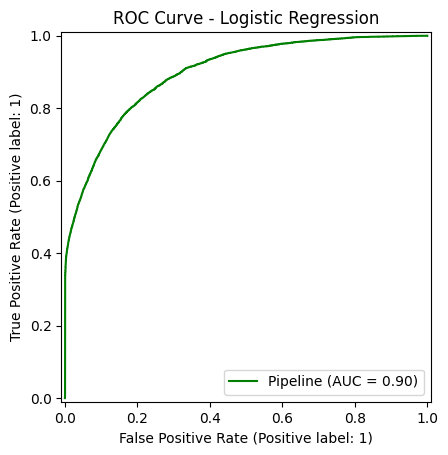

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(log_model, X_test, y_test, color="green")
plt.title("ROC Curve - Logistic Regression")
plt.show()
